# Do Late Deliveries Hurt Customer Satisfaction? (Olist E-Commerce)

**Business question:** How much do late deliveries affect customer reviews and repeat purchases, and where should the company fix delivery first?

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle). Tables used: orders, customers, order items, reviews.

**Tools:** Python (pandas, matplotlib), SQL (SQLite), Tableau Public.

## Step 1: Load the data
Load the four CSV files and check how many rows and columns each one has.

In [ ]:
import pandas as pd

orders = pd.read_csv('/olist_orders_dataset.csv')
customers = pd.read_csv('/olist_customers_dataset.csv')
reviews = pd.read_csv('/olist_order_reviews_dataset.csv')
items = pd.read_csv('/olist_order_items_dataset.csv')

for name, df in [('orders', orders), ('customers', customers), ('reviews', reviews), ('items', items)]:
    print(name, df.shape)

orders.head()

orders (99441, 8)
customers (99441, 5)
reviews (99224, 7)
items (112650, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Step 2: Clean the data and define "late"
- Keep only delivered orders (cancelled orders cannot be late).
- Convert date columns from text to dates.
- Remove delivered orders with no delivery date.
- Create three metrics: delivery days, delay days (delivered date minus estimated date), and a late flag (1 if delay is above 0).

In [ ]:
# 1. Keep only orders that were actually delivered
df = orders[orders['order_status'] == 'delivered'].copy()

# 2. Convert the date columns from text into real dates
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# 3. Remove orders that have no delivery date (we can't measure them)
df = df.dropna(subset=['order_delivered_customer_date'])

# 4. Create the key metrics
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = (df['delay_days'] > 0).astype(int)

# 5. Check the results
print("Delivered orders:", len(df))
print("Percentage late:", round(df['is_late'].mean() * 100, 1), "%")
print("Average delivery time:", round(df['delivery_days'].mean(), 1), "days")

df[['order_id', 'delivery_days', 'delay_days', 'is_late']].head()

Delivered orders: 96470
Percentage late: 6.8 %
Average delivery time: 12.1 days


,order_id,delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,8,-8,0
1,53cdb2fc8bc7dce0b6741e2150273451,13,-6,0
2,47770eb9100c2d0c44946d9cf07ec65d,9,-18,0
3,949d5b44dbf5de918fe9c16f97b45f8a,13,-13,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2,-10,0


## Step 3: Do late orders get lower review scores?
Join each order's review score to the delivery table using order_id, then compare the average score for on-time vs late orders.

**Result:** On-time orders average 4.29 stars, late orders average 2.27 stars (95,824 orders analyzed).

In [ ]:
# 1. Keep one review per order (some orders have duplicates)
reviews_clean = reviews[['order_id', 'review_score']].drop_duplicates(subset='order_id')

# 2. Attach each order's review score to our delivery table
df = df.merge(reviews_clean, on='order_id', how='left')

# 3. Drop orders that have no review
df = df.dropna(subset=['review_score'])

# 4. Compare average review score: on-time vs late
print(df.groupby('is_late')['review_score'].mean().round(2))
print("Orders with reviews:", len(df))

is_late
0    4.29
1    2.27
Name: review_score, dtype: float64
Orders with reviews: 95824


### Review score by length of delay
Group orders into delay buckets to see whether longer delays do more damage.

**Result:** Scores fall as delays grow: 4.29 (on time), 3.29 (1-3 days late), 2.11 (4-7 days late), 1.70 (7+ days late).

delay_bucket
On time          4.29
1-3 days late    3.29
4-7 days late    2.11
7+ days late     1.70
Name: review_score, dtype: float64


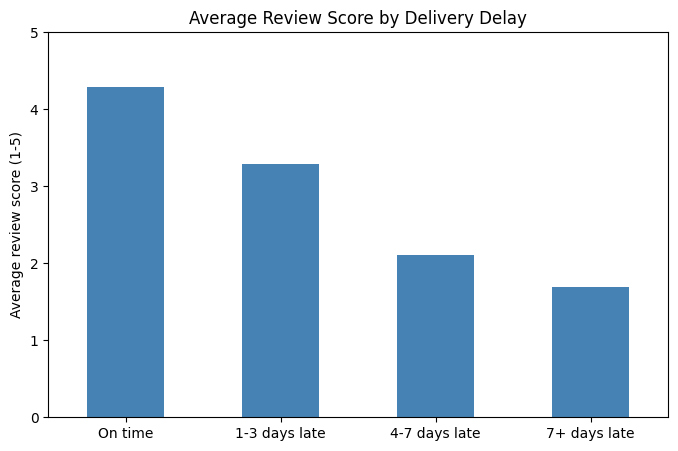

In [ ]:
import matplotlib.pyplot as plt

# Group delays into buckets
df['delay_bucket'] = pd.cut(
    df['delay_days'],
    bins=[-1000, 0, 3, 7, 1000],
    labels=['On time', '1-3 days late', '4-7 days late', '7+ days late']
)

bucket_scores = df.groupby('delay_bucket', observed=True)['review_score'].mean()
print(bucket_scores.round(2))

# Draw a bar chart
bucket_scores.plot(kind='bar', color='steelblue', figsize=(8, 5))
plt.title('Average Review Score by Delivery Delay')
plt.ylabel('Average review score (1-5)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.show()

## Step 4: Do customers with a late first order come back less often?
Use customer_unique_id to identify real customers, find each customer's first order, and check whether they ordered again.

**Result:** 3.01% of customers with an on-time first order ordered again, vs 2.56% with a late first order. Repeat purchases are rare overall and the gap is small, so this shows a pattern, not proof of cause.

In [ ]:
# 1. Add the unique customer ID (the same person can have several customer_id values)
d = df.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# 2. Sort orders by purchase time, so each customer's first order comes first
d = d.sort_values('order_purchase_timestamp')

# 3. Count how many orders each customer made in total
total_orders = d.groupby('customer_unique_id')['order_id'].count()

# 4. Keep only each customer's FIRST order
first = d.groupby('customer_unique_id').first()
first['total_orders'] = total_orders
first['came_back'] = (first['total_orders'] > 1).astype(int)

# 5. Compare the return rate: first order on time vs late
result = first.groupby('is_late')['came_back'].agg(['mean', 'count'])
result['mean'] = (result['mean'] * 100).round(2)
result.columns = ['return_rate_%', 'customers']
result.index = ['First order on time', 'First order late']
print(result)

                     return_rate_%  customers
First order on time           3.01      86533
First order late              2.56       6214


## Step 5: Revenue impact
Calculate how much revenue came from late orders and estimate lost repeat revenue.

**Result:** About 7.3% of revenue (953K of 13.1M BRL) came from late orders. Estimated lost repeat revenue is small (about 28 customers, 3,825 BRL).

**Assumption:** If customers with a late first order had returned at the on-time rate, about 28 more would have come back, each worth the average order value (137 BRL).

In [ ]:
# 1. Revenue per order (sum of item prices)
order_revenue = items.groupby('order_id')['price'].sum().reset_index()
order_revenue.columns = ['order_id', 'revenue']
df = df.merge(order_revenue, on='order_id', how='left')

# 2. How much revenue came from late orders?
total_rev = df['revenue'].sum()
late_rev = df.loc[df['is_late'] == 1, 'revenue'].sum()
print("Total revenue:", round(total_rev))
print("Revenue from late orders:", round(late_rev), f"({late_rev / total_rev * 100:.1f}%)")

# 3. Estimated lost repeat revenue (assumption-based)
avg_order_value = df['revenue'].mean()
late_customers = result.loc['First order late', 'customers']
gap = (result.loc['First order on time', 'return_rate_%'] - result.loc['First order late', 'return_rate_%']) / 100
lost_customers = late_customers * gap
print("Average order value:", round(avg_order_value))
print("Estimated customers lost to late delivery:", round(lost_customers))
print("Estimated lost repeat revenue:", round(lost_customers * avg_order_value))

Total revenue: 13108744
Revenue from late orders: 953367 (7.3%)
Average order value: 137
Estimated customers lost to late delivery: 28
Estimated lost repeat revenue: 3825


### Late delivery rate by state
**Result:** Late deliveries are concentrated in the northeast: Alagoas (AL) 20.8%, Maranhao (MA) 17.1%, Sergipe (SE) 15.0%, vs 6.7% overall.

customer_state
AL    20.8
MA    17.1
SE    15.0
PI    13.8
CE    13.7
RR    12.2
RJ    11.9
BA    11.9
PA    10.7
ES    10.4
Name: is_late, dtype: float64


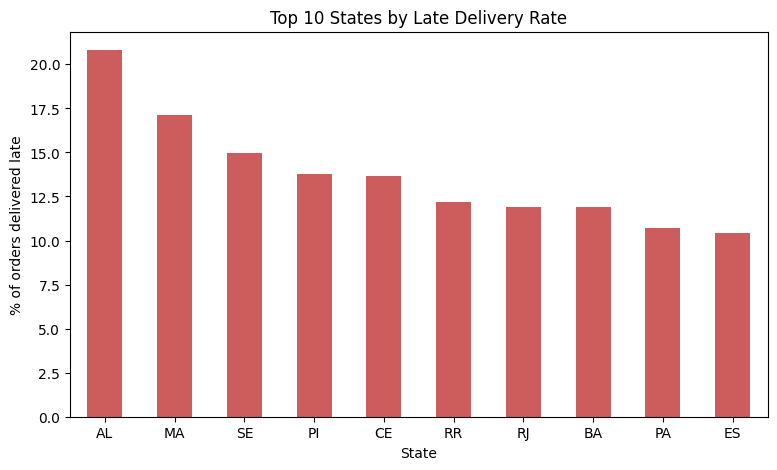

In [ ]:
df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

state_late = (df.groupby('customer_state')['is_late'].mean() * 100).sort_values(ascending=False).head(10)
print(state_late.round(1))

state_late.plot(kind='bar', color='indianred', figsize=(9, 5))
plt.title('Top 10 States by Late Delivery Rate')
plt.ylabel('% of orders delivered late')
plt.xlabel('State')
plt.xticks(rotation=0)
plt.show()

### Repeat purchase rate: on-time vs late first order
A chart of the Step 4 result.

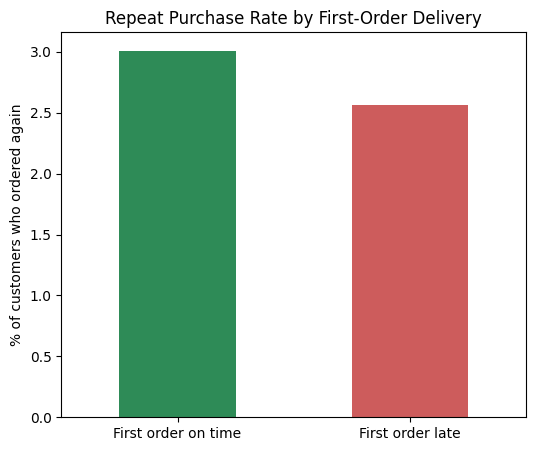

In [ ]:
result['return_rate_%'].plot(kind='bar', color=['seagreen', 'indianred'], figsize=(6, 5))
plt.title('Repeat Purchase Rate by First-Order Delivery')
plt.ylabel('% of customers who ordered again')
plt.xticks(rotation=0)
plt.show()

## Step 6: Validate the results with SQL
Copy the cleaned table into a SQLite database and re-answer the key questions with SQL queries (aggregations, GROUP BY, HAVING, JOIN).

**Query 1:** What percentage of orders are late? (6.7%)
**Query 2:** Average review score, on-time vs late. (4.29 vs 2.27)

In [ ]:
import sqlite3

# Create a small in-memory SQL database from our tables
conn = sqlite3.connect(':memory:')
df.to_sql('orders_clean', conn, index=False)
customers.to_sql('customers', conn, index=False)

def sql(query):
    return pd.read_sql_query(query, conn)

# Query 1: What percentage of orders are late?
sql("""
SELECT ROUND(AVG(is_late) * 100, 1) AS pct_late,
       COUNT(*) AS total_orders
FROM orders_clean
""")

,pct_late,total_orders
0,6.7,95824


In [ ]:
# Query 2: Average review score, on-time vs late
sql("""
SELECT is_late,
       COUNT(*) AS orders,
       ROUND(AVG(review_score), 2) AS avg_review
FROM orders_clean
GROUP BY is_late
""")

,is_late,orders,avg_review
0,0,89443,4.29
1,1,6381,2.27


**Query 3:** Worst states by late rate (states with at least 100 orders). Matches the Python result.

In [ ]:
sql("""
SELECT customer_state,
       COUNT(*) AS orders,
       ROUND(AVG(is_late) * 100, 1) AS pct_late,
       ROUND(AVG(review_score), 2) AS avg_review
FROM orders_clean
GROUP BY customer_state
HAVING COUNT(*) >= 100
ORDER BY pct_late DESC
LIMIT 10
""")

,customer_state,orders,pct_late,avg_review
0,AL,394,20.8,3.86
1,MA,712,17.1,3.83
2,SE,334,15.0,3.91
3,PI,471,13.8,3.99
4,CE,1273,13.7,3.94
5,RJ,12211,11.9,3.96
6,BA,3229,11.9,3.93
7,PA,933,10.7,3.91
8,ES,1969,10.4,4.08
9,PB,512,10.2,4.08


**Query 4:** Worst cities by late rate, using a JOIN with the customers table (cities with at least 200 orders).

**Result:** Maceio 26.5%, Sao Goncalo 21.9%, Teresina 18.7%, Sao Luis 18.7%.

In [ ]:
sql("""
SELECT c.customer_city,
       COUNT(*) AS orders,
       ROUND(AVG(o.is_late) * 100, 1) AS pct_late
FROM orders_clean o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_city
HAVING COUNT(*) >= 200
ORDER BY pct_late DESC
LIMIT 10
""")

,customer_city,orders,pct_late
0,maceio,234,26.5
1,sao goncalo,379,21.9
2,teresina,267,18.7
3,sao luis,332,18.7
4,macae,225,15.6
5,fortaleza,614,15.1
6,volta redonda,224,14.3
7,salvador,1172,14.2
8,aracaju,213,13.6
9,vila velha,318,13.5


## Step 7: Export clean data for the Tableau dashboard
Save the cleaned table as a CSV, which was used to build the dashboard in Tableau Public.

In [ ]:
export = df[['order_id', 'customer_state', 'order_purchase_timestamp',
             'delivery_days', 'delay_days', 'is_late', 'review_score',
             'delay_bucket', 'revenue']].copy()
export['status'] = export['is_late'].map({0: 'On time', 1: 'Late'})
export.to_csv('olist_clean_for_dashboard.csv', index=False)
print(export.shape)

(95824, 10)


In [ ]:
from google.colab import files
files.download('olist_clean_for_dashboard.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Findings and recommendations

## Key findings
1. 6.7% of delivered orders arrived after the estimated date.
2. Late orders averaged 2.27 stars vs 4.29 for on-time orders, and the longer the delay, the lower the score (1.70 stars at 7+ days late).
3. Customers whose first order was late returned slightly less often (2.56% vs 3.01%).
4. Late deliveries concentrate in the northeast: AL 20.8%, MA 17.1%, SE 15.0%. The city of Maceio reached 26.5%.
5. About 7.3% of revenue came from orders that arrived late.

## Recommendations
1. Prioritize delivery improvements in AL, MA, and SE, starting with cities like Maceio, Teresina, and Sao Luis.
2. Add buffer days to delivery estimates in high-delay regions.
3. Proactively message customers when an order is running late.

## Limitations
- Only delivered orders that have a review were analyzed.
- Repeat purchases are rare in this dataset, so the retention effect is small and should not be read as proof of cause.
- The lost-revenue estimate rests on a simple assumption and is conservative.